In [3]:
import pandas as pd
import numpy as np

#Part A
df = pd.read_csv("Canadian_Health_Survey_Sample.csv")
df.head()
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Province          850 non-null    object 
 1   Gender            850 non-null    object 
 2   Age               850 non-null    int64  
 3   Income            816 non-null    float64
 4   BMI               808 non-null    float64
 5   PhysicalActivity  825 non-null    float64
 6   Smoking           850 non-null    object 
 7   SelfRatedHealth   850 non-null    object 
 8   StressLevel       825 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 59.9+ KB


,Province,Gender,Age,Income,BMI,PhysicalActivity,Smoking,SelfRatedHealth,StressLevel
count,850,850,850.000000,816.000000,808.000000,825.000000,850,850,825.000000
unique,10,6,NaN,NaN,NaN,NaN,6,5,NaN
top,Quebec,Male,NaN,NaN,NaN,NaN,No,Good,NaN
freq,100,230,NaN,NaN,NaN,NaN,552,258,NaN
mean,NaN,NaN,49.517647,77461.917892,27.488861,3.511394,NaN,NaN,5.294545
std,NaN,NaN,18.192604,22497.833440,5.064344,1.925825,NaN,NaN,2.121156
min,NaN,NaN,18.000000,5000.000000,13.500000,0.000000,NaN,NaN,1.000000
25%,NaN,NaN,33.000000,63438.000000,24.000000,2.100000,NaN,NaN,4.000000
50%,NaN,NaN,49.000000,78130.000000,27.300000,3.500000,NaN,NaN,5.000000
75%,NaN,NaN,66.000000,90529.500000,30.900000,4.700000,NaN,NaN,7.000000


## A3:
Income is a quantitative attribute because it represents a numeric value that is measureable.
SelfRatedHealth is a qualitative attribute since is descriptive and expressed using language, not numbers. Use words or labels to describe certain characteristics, in this case the individual's rating of their health.

In [6]:
#Part B

#normalize gender values
df['Gender'] = df['Gender'].replace({
    'M': 'Male',
    'male': 'Male',
    'F': 'Female',
    'female': 'Female'
})

#normalize smoking values
df['Smoking'] = df['Smoking'].replace({
    'Y': 'Yes',
    'yes': 'Yes',
    'N': 'No',
    'no': 'No'
})

#handle missing values
# for each variable, there are between 2-5% of that data missing out of all entries
# thus imputation was used to not lose data 
# median was chosen due to variability and potential skewness of column values
df['BMI'] = df['BMI'].fillna(df['BMI'].median())
df['Income'] = df['Income'].fillna(df['Income'].median())
df['PhysicalActivity'] = df['PhysicalActivity'].fillna(df['PhysicalActivity'].median())
df['StressLevel'] = df['StressLevel'].fillna(df['StressLevel'].median())

#enforce data types
df['Age'] = df['Age'].astype('int64')
df['Income'] = df['Income'].astype('float64')
df['BMI'] = df['BMI'].astype('float64')
df['StressLevel'] = df['StressLevel'].astype('int64')

#create derived columns
df['BMI_Category'] = np.where(
    df['BMI'] < 18.5, 'Underweight',
    np.where(df['BMI'] < 25, 'Normal',
    np.where(df['BMI'] < 30, 'Overweight', 'Obese'))
)

df['IncomeBracket'] = np.where(
    df['Income'] < 50000, '<50K',
    np.where(df['Income'] < 80000, '50-80k',
    np.where(df['Income'] < 110000, '80-110k', '>110k'))
)

#output cleaned data into a new csv
df.to_csv("Canadian_Health_Survey_Cleaned.csv", index=False)


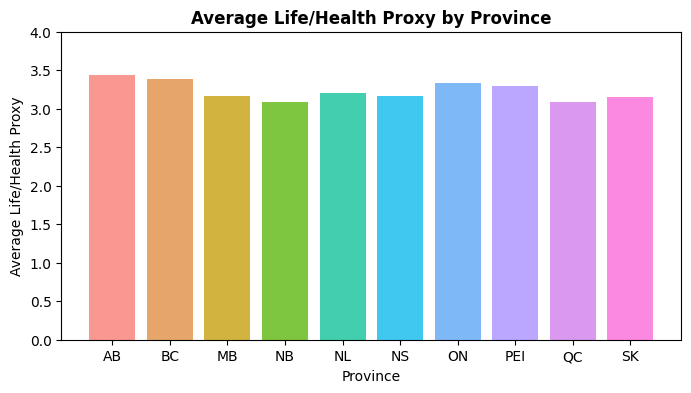

In [9]:
#Part C
import matplotlib.pyplot as plt

#bar chart

health_map = {
    'Poor': 1,
    'Fair': 2,
    'Good': 3,
    'Very Good': 4,
    'Excellent': 5
}

province_initials = {
    'Alberta': 'AB',
    'British Columbia': 'BC',
    'Manitoba': 'MB',
    'New Brunswick': 'NB',
    'Newfoundland and Labrador': 'NL',
    'Nova Scotia': 'NS',
    'Ontario': 'ON',
    'Prince Edward Island': 'PEI',
    'Quebec': 'QC',
    'Saskatchewan': 'SK'
}
         
df['SelfRatedHealth_num'] = df['SelfRatedHealth'].map(health_map)
df['Province_initials'] = df['Province'].map(province_initials)
province_health = df.groupby('Province_initials')['SelfRatedHealth_num'].mean()

# qualitative colour scale to differentiate provinces (discrete categories)
colours = ['#F8766D', '#DE8837', '#C49A00', '#53B400', '#02C094', '#00B6EB', '#53A0F5', '#A58AFF', '#D076EB', '#FB61D7']

plt.figure(figsize=(8,4))
plt.bar(province_health.index, province_health.values, color=colours, alpha=0.75)
plt.xlabel('Province')
plt.ylabel('Average Life/Health Proxy')
plt.ylim(0, 4) # increase y limit to add more white space
plt.title('Average Life/Health Proxy by Province', fontweight='bold')
plt.show()

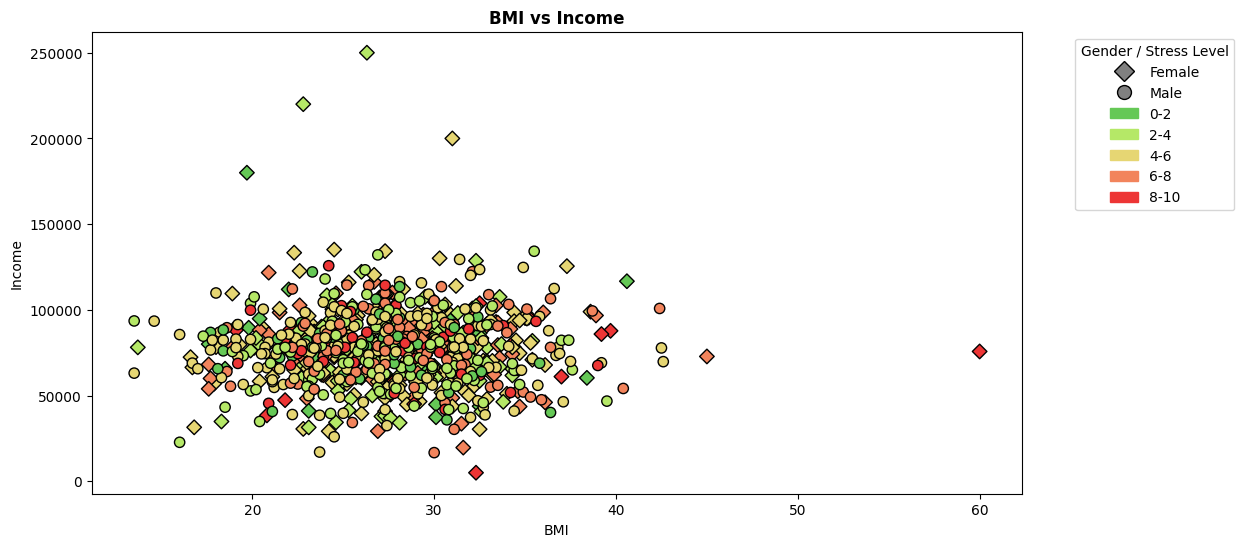

In [10]:
#scatter plot

bins = [0, 2, 4, 6, 8, 10]
labels = ['0-2','2-4','4-6','6-8','8-10']
df['StressBin'] = pd.cut(df['StressLevel'], bins=bins, labels=labels)
#sequential colour scale for stress level (green -> red to show low stress -> high stress) to show levels clearly
colours = {
    '0-2': '#65C856',  
    '2-4': '#B5E867', 
    '4-6': '#E6D673',  
    '6-8': '#F2845C',  
    '8-10':'#ED3535'   
}
df['StressColor'] = df['StressBin'].map(colours)

#diamond = female, circle = male
markers = {'Female': 'D','Male':'o'}

plt.figure(figsize=(12,6))

for gender in df['Gender'].unique():
    subset = df[df['Gender'] == gender]
    plt.scatter(
        subset['BMI'],
        subset['Income'],
        facecolors=subset['StressColor'], 
        marker=markers[gender],   
        s=55,
        label=gender,
        edgecolor='black'
    )

plt.xlabel("BMI")
plt.ylabel("Income")
plt.title("BMI vs Income", fontweight='bold')

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

marker_handles = [Line2D([0], [0], marker=markers[g], color='w', markerfacecolor='gray', 
                  markersize=10, markeredgecolor='black', label=g) 
                  for g in markers]
color_handles = [mpatches.Patch(color=v, label=k) for k,v in colours.items()]
plt.legend(handles=marker_handles + color_handles, bbox_to_anchor=(1.05, 1), loc='upper left', title='Gender / Stress Level')

plt.show()

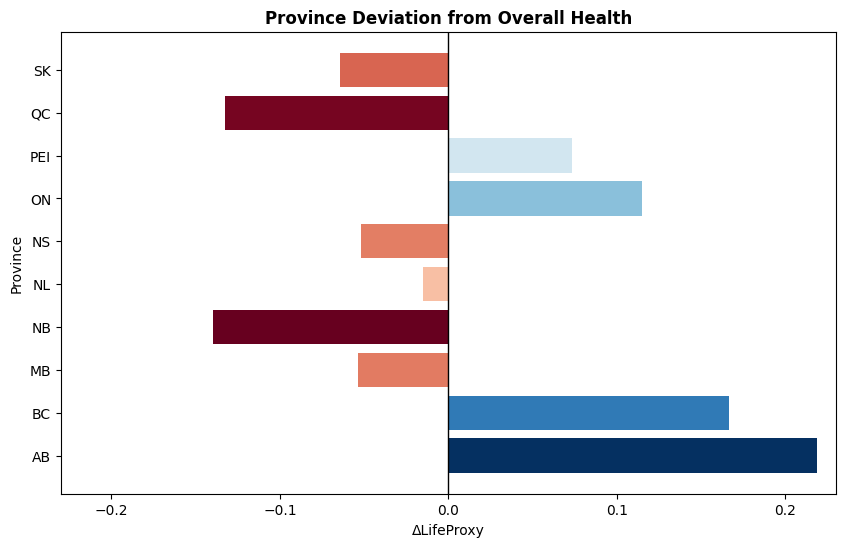

In [11]:
#diverging visualization

overall_mean = df['SelfRatedHealth_num'].mean()
delta = province_health - overall_mean

plt.figure(figsize=(10,6))
#use diverging colour scale to show the difference from the midline (positive vs negative delta)
bars = plt.barh(delta.index, delta.values, color=plt.cm.RdBu((delta.values - delta.values.min()) / (delta.values.max() - delta.values.min())))
plt.axvline(0, color='black', linewidth=1) 

plt.xlabel("ΔLifeProxy")
plt.xlim(-0.23,0.23)
plt.ylabel("Province")
plt.title("Province Deviation from Overall Health", fontweight='bold')

plt.show()

## Part C4

** Colour Scale **
For each graph a color scale that matched the type of data shown was used.
For C1: used a qualitative color scale as the provinces are discrete categories. 
For C2: used a sequential color scale from green to red to show the levels of stress from 0-10.
For C3: used a diverging colour scale to show deviation from the midpoint for each province.

** Cognitive Load **
For both C1 and C3, province names were shorten to their initials to reduce cognitive load and to compact information.
Each title is bolded to add emphasis to what the plot is about, reducing need to search for it.
Colours used for each graph are not overly vibrant in comparison to each other so no single bar draws attention away unnecessarily.
For C2: a single legend combines marker shape and colour bins to reduce cross-referencing, and used more intuitive colours to aid understanding.

** Contiguity **
Spatial contiguity was applied by placing legends and labels close to the visual elements they describe.
For example, in C2 the combined legend is positioned adjacent to the scatter plot, minimizing the need for viewers to shift attention between distant parts of the figure.
This proximity helps reduce split attention and supports more efficient interpretation of the encoded variables.

## Part D : Interpretation

** D1: **
The average health/life proxy is roughly the same for each province. This suggests that self-rated health does not vary substantially by province in this dataset. Overall indicates relatively similar perceived outcomes across regions.

Majority of people are clustered around 50K - 100K income and 20-40 BMI with varying levels of stress. This clustering reflects the typical range in the population and overall population norms rather than a strong relationship between variables. A few of the outliers show lower stress levels for higher income, but this doesn't apply to the larger cluster of people. There doesn't seem to be any gender-based separation or large deviation in stress levels in relation to BMI or income.

Generally west regions have more positive delta (AB and BC) with east regions having more negative delta (NB, NL, and NS). However, all provinces do not deviate far from the midpoint being between -0.2 and 0.25. This illustrates that the provinces average health is not far off from Canada's health as a whole. No province appears as a strong outlier, as all deviations fall within a narrow range around the overall mean.

** D2: **
One limitation of the data is the health rating being from self-report which can introduce social desirability factors and can be subjective to the person answering it. This can reduce comparability across participants, as different individuals may interpret categories such as “Good” or “Excellent” differently.